# TODO

jobs STARTED IN OR AFTER year of graduation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import networkx as nx
import re
from plotnine import ggplot, aes
import plotnine as p9
from wordcloud import WordCloud

plt.style.use("ggplot")

output = "output/csv/"
input = "input/"
figures = "figures/"
uk = ["England", "Scotland", "Wales", "Northern Ireland"]

papers = pd.read_excel(f"{input}students.xlsx", sheet_name="Papers").drop_duplicates(
    subset=["DOI"], keep="first"
)
students = pd.read_excel(f"{input}students.xlsx", sheet_name="Students")
jobs = pd.read_excel(f"{input}students.xlsx", sheet_name="Jobs")

students = students[students.Year != 2020]


to_exclude = [0, "0", np.nan, "nan", "None", "none", "", "Not Found", "Error"]

# add end date for all students
names_to_exclude = []
jobs.end_date = np.nan
for name in jobs.Name.unique():
    if name in students.Name.unique():
        relevant_row = students.loc[students.Name == name]
        # Check if the relevant row is empty
        year = relevant_row["Thesis Year"].values[0]
        if pd.isna(year):
            names_to_exclude.append(name)
        else:
            jobs.loc[jobs.Name == name, "end_date"] = year

    else:
        print(f"Name {name} not found in students list")

# remove students with no end date
jobs = jobs[~jobs.Name.isin(names_to_exclude)]

# get the year only of the start date, as an int
jobs["start_year"] = jobs["Start date"].copy()
jobs["start_year"] = (
    jobs["start_year"].astype(str).str.extract(r"(\d{4})")[0].astype(float)
)
# get the year of the end date

jobs["years_since"] = jobs.apply(
    lambda x: x.start_year - x.end_date
    if x.end_date != np.nan and x.start_year != np.nan
    else np.nan,
    axis=1,
)

# remove jobs before end date
jobs = jobs[jobs.years_since >= 0]

# Alumni Project Dashboard
## Summary
This dashboard contains information about the data collected and analysed
as part of the alumni project. I have grouped plots and summaries by theme
which you can access using the dropdowns (hopefully)!

## Data collection summary

Because part of the project is to collect and clean data, I'll start by demonstrating
the progress made in the data collection. 

### What is the structure of the data?

The data is stored in an Excel spreadsheet. There are three areas of data collection:
- Alumni information: each student is assigned a unique identifier. Their course, prior institutions and current location are listed.
- Alumni jobs: for each alumnus, this records (where known) each job they have held since leaving the DTC, including employer, title, start and end dates and location.
- Alumni publications: for each alumnus, this records all publications we've been able to find that they have published. This records title, authors, journal, year and DOI.

### A note on terminology
I use 'student' to refer to an individual prior to or suring their time at the DTC, after which they are alumni.

## Where are they now?

The following plots shows the distribution of where students are now. We
can look at country and intitution of both the undergraduate and
postgraduate study.

Firstly, on the top level, we can look at what continents graduates have
found themselves in.

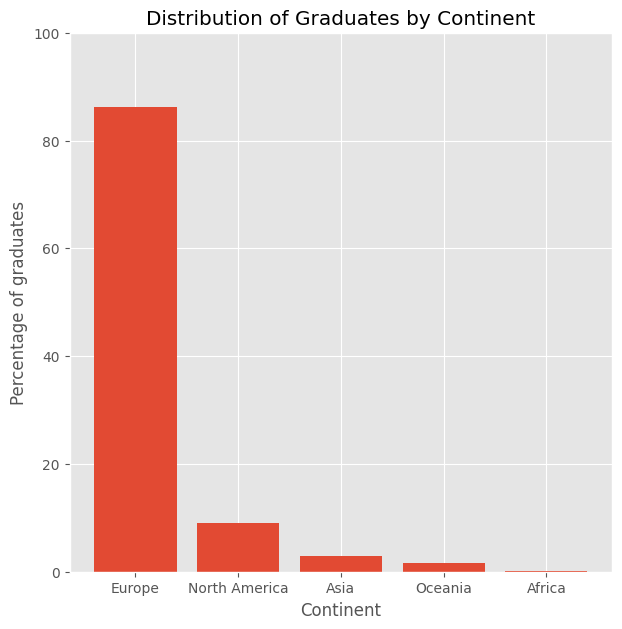

In [2]:
plt.figure(figsize=(7, 7))
# how many in each continent
counts = students["Continent"].value_counts().reset_index()
counts.columns = ["Continent", "count"]
counts["percent"] = counts["count"] / counts["count"].sum() * 100
# plt.pie(counts["Continent"], labels=counts["index"], autopct="%1.1f%%")
plt.bar(
    x=counts["Continent"].to_list(),
    height=counts["percent"],
)
plt.title("Distribution of Graduates by Continent")
plt.ylim(0, 100)
plt.xlabel("Continent")
plt.ylabel("Percentage of graduates")
plt.savefig(f"{figures}continent_pie.png")
plt.show()

The overwhelming majority are (perhaps predictably) in Europe, with North America far behind in second place. Let's break that down by country.

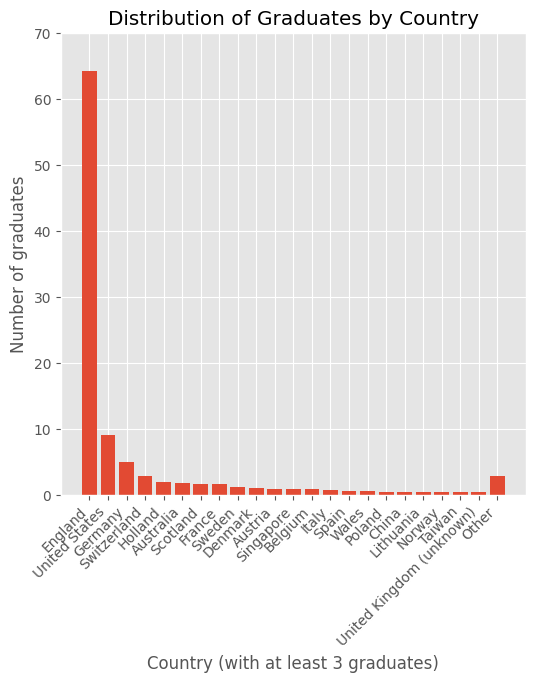

In [3]:
# graduates by country
plt.figure(figsize=(6, 6))
limit = 3
counts = students["Country"].value_counts().reset_index()
counts = counts.sort_values("count", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
other = counts[counts["count"] < limit]
counts = counts[counts["count"] >= limit]
counts.loc[len(counts)] = ["Other", other["count"].sum(), other["percent"].sum()]
# plt.pie(counts["Country"], labels=counts["index"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of Graduates by Country")
plt.xlabel("Country (with at least 3 graduates)")
plt.ylabel("Number of graduates")
plt.xticks(rotation=45, ha="right")
plt.savefig(f"{figures}country_pie.png")
plt.ylim(0, 70)
plt.show()

Unsurprisingly, the UK is the most popular destination. The pie chart also shows that the overwhelming majority of students in North America are in the US.

We can take a quick look at where graduates have gone outside of the UK in Europe.

Germany is the most popular destination, with Switzerland and Holland following behind.

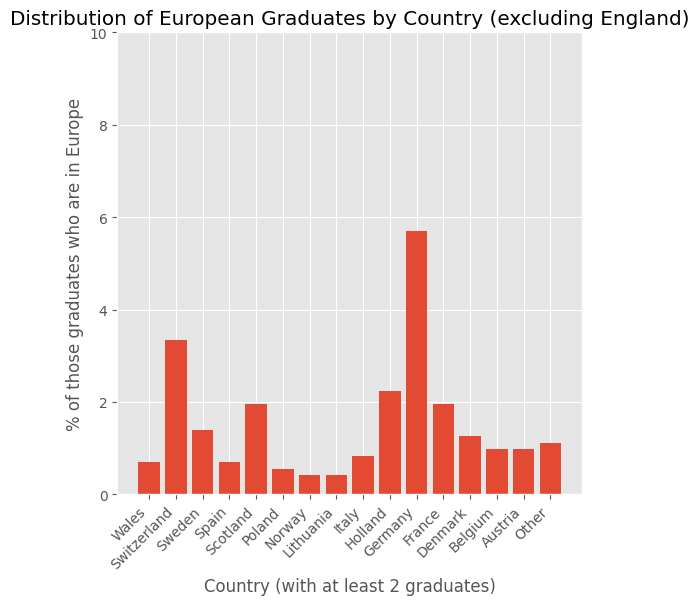

In [4]:
plt.figure(figsize=(6, 6))
# europe without the UK
limit = 2
counts = (
    students[students["Continent"] == "Europe"]["Country"].value_counts().reset_index()
)
counts = counts.sort_values("Country", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
counts = counts[counts["Country"] != "England"]
counts = counts[counts["Country"] != "United Kingdom (unknown)"]
other = counts[counts["count"] < limit]
counts = counts[counts["count"] > limit]
counts.loc[len(counts)] = ["Other", other["count"].sum(), other["percent"].sum()]
# plt.pie(counts["count"], labels=counts["Country"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of European Graduates by Country (excluding England)")
plt.xlabel("Country (with at least 2 graduates)")
plt.ylabel("% of those graduates who are in Europe")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 10)
plt.savefig(f"{figures}europe_nouk_country_pie.png")
plt.show()

And where graduates have gone OUTSIDE Europe...

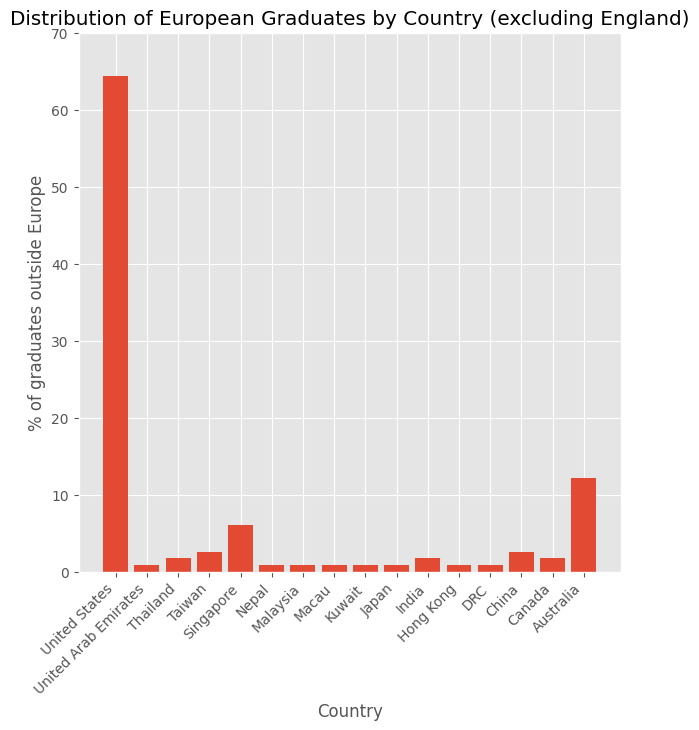

In [5]:
plt.figure(figsize=(7, 7))
# europe without the UK
limit = 0
counts = (
    students[students["Continent"] != "Europe"]["Country"].value_counts().reset_index()
)
counts = counts.sort_values("Country", ascending=False)
counts["percent"] = counts["count"] / counts["count"].sum() * 100
# plt.pie(counts["count"], labels=counts["Country"], autopct="%1.1f%%")
plt.bar(x=counts["Country"], height=counts["percent"])
plt.title("Distribution of European Graduates by Country (excluding England)")
plt.xlabel("Country")
plt.ylabel("% of graduates outside Europe")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 70)
plt.savefig(f"{figures}europe_nouk_country_pie.png")
plt.show()

Finally, we can look at where graduates have gone in the UK.

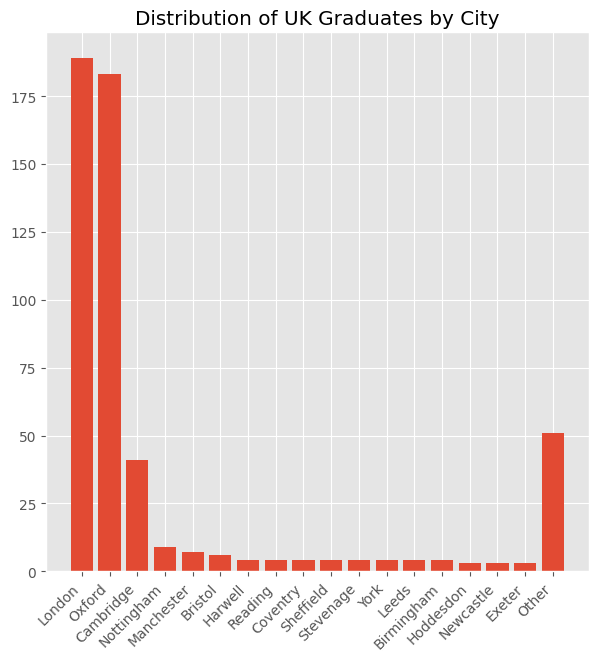

In [6]:
plt.figure(figsize=(7, 7))
# if UK, where are they?
limit = 2
counts = students[students["Country"] == "England"]["City"].value_counts().reset_index()
counts.columns = ["index", "City"]
counts = counts.sort_values("City", ascending=False)
other = counts[counts["City"] < limit]
counts = counts[counts["City"] > limit]
counts.loc[len(counts)] = ["Other", other["City"].sum()]
plt.bar(counts["index"], counts["City"])
# plt.pie(counts["City"], labels=counts["index"], autopct="%1.1f%%")
# plt.axis("equal")
plt.title("Distribution of UK Graduates by City")
plt.savefig(f"{figures}uk_city_pie.png")
# rotate x labels
plt.xticks(rotation=45, ha="right")
plt.show()


We can also look at whether graduates remained in the same country as that which they studied in prior to the DTC.
Additionally, did people stay in Oxford specifically? That is, if they studied in Oxford prior to the DTC, did they stay in Oxford? If they didn't, did they remain there after leaving the DTC?

In [7]:
# plotly sankey diagram for where students were before and after the course
counts = students.loc[:, ["PGUniversity", "City"]]
counts["last_known"] = counts["PGUniversity"].copy()
counts.loc[counts["last_known"].isna(), "last_known"] = students["UGUniversity"]
counts["place"] = None
counts.loc[counts["last_known"] == counts["City"], "place"] = "Stayed (Other)"
counts.loc[counts["last_known"] != counts["City"], "place"] = "Moved (Other)"
counts.loc[(counts["last_known"].isna()) & (counts["City"].isna()), "place"] = (
    "Not Known"
)
counts.loc[(counts["last_known"] == 0) & (counts["City"] == 0), "place"] = "Not Known"
counts.loc[
    (counts["last_known"] == "Oxford") & (counts["City"] == "Oxford"), "place"
] = "Stayed in Oxford"
counts.loc[
    (counts["last_known"] != "Oxford") & (counts["City"] == "Oxford"), "place"
] = "Moved to Oxford"
counts.loc[
    (counts["last_known"] == "Oxford") & (counts["City"] != "Oxford"), "place"
] = "Moved from Oxford"
counts.loc[(counts["last_known"].isna()) & (counts["City"] != "Oxford"), "place"] = (
    "Unknown to Elsewhere"
)
counts.loc[(counts["last_known"].isna()) & (counts["City"] == "Oxford"), "place"] = (
    "Unknown to Oxford"
)
counts.loc[(counts["last_known"] == "Oxford") & (counts["City"].isna()), "place"] = (
    "Oxford to Unknown"
)
counts.loc[(counts["last_known"] != "Oxford") & (counts["City"].isna()), "place"] = (
    "Elsewhere to Unknown"
)

counts = counts["place"].value_counts().reset_index()
counts.columns = ["index", "place"]
# set index to 'index' column
counts = counts.set_index("index")
counts = counts.T
display(counts)

not_known_at_all = counts["Not Known"] if "Not Known" in counts else 0

labels = ["Oxford", "Elsewhere", "Not Known", "Oxford", "Elsewhere", "Not Known"]
sources = [0, 0, 0, 1, 1, 1, 2, 2, 2]
target = [3, 4, 5, 3, 4, 5, 3, 4, 5]
value = [
    counts["Stayed in Oxford"],
    counts["Moved from Oxford"],
    counts["Oxford to Unknown"],
    counts["Moved to Oxford"],
    counts["Moved (Other)"],
    counts["Elsewhere to Unknown"],
    counts["Unknown to Oxford"],
    counts["Unknown to Elsewhere"],
    not_known_at_all,
]

label_color = [
    "steelblue",
    "crimson",
    "yellowgreen",
    "steelblue",
    "crimson",
    "yellowgreen",
]
link_color = [
    "steelblue",
    "orchid",
    "darkcyan",
    "purple",
    "crimson",
    "maroon",
    "grey",
    "turquoise",
    "yellowgreen",
]

node = dict(
    label=labels,
    color=label_color,
    pad=15,
    thickness=15,
    line=dict(color="black", width=0.5),
)
link = dict(source=sources, target=target, value=value, color=link_color)
figure = go.Figure(go.Sankey(link=link, node=node))
figure.show()

index,Moved (Other),Elsewhere to Unknown,Moved from Oxford,Moved to Oxford,Stayed in Oxford,Stayed (Other),Unknown to Elsewhere,Unknown to Oxford,Oxford to Unknown
place,467,206,164,140,41,10,5,2,2


In [8]:
# plotly sankey diagram for where students were before and after the course
counts = students.loc[:, ["PGCountry", "Country"]]
counts["last_known"] = counts["PGCountry"].copy()
counts.loc[counts["last_known"].isna(), "last_known"] = students["UGCountry"]
counts["place"] = None
counts.loc[counts["last_known"] == counts["Country"], "place"] = "Stayed (Other)"
counts.loc[counts["last_known"] != counts["Country"], "place"] = "Moved (Other)"
counts.loc[(counts["last_known"].isna()) & (counts["Country"].isna()), "place"] = (
    "Not Known"
)
counts.loc[(counts["last_known"] == 0) & (counts["Country"] == 0), "place"] = (
    "Not Known"
)
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"] == "England"), "place"
] = "Stayed in England"

print(counts[counts["last_known"] == "England"].shape)
print(counts[counts["Country"] == "England"].shape)

counts.loc[
    (counts["last_known"] != "England") & (counts["Country"] == "England"), "place"
] = "Moved to England"
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"] != "England"), "place"
] = "Moved from England"
counts.loc[
    (counts["last_known"].isna()) & (counts["Country"] != "England"), "place"
] = "Unknown to Elsewhere"
counts.loc[
    (counts["last_known"].isna()) & (counts["Country"] == "England"), "place"
] = "Unknown to England"
counts.loc[
    (counts["last_known"] == "England") & (counts["Country"].isna()), "place"
] = "England to Unknown"
counts.loc[
    (counts["last_known"] != "England") & (counts["Country"].isna()), "place"
] = "Elsewhere to Unknown"

counts = counts["place"].value_counts().reset_index()
counts.columns = ["index", "place"]
# set index to 'index' column
counts = counts.set_index("index")
counts = counts.T

not_known_at_all = counts["Not Known"] if "Not Known" in counts else 0

labels = ["England", "Elsewhere", "Not Known", "England", "Elsewhere", "Not Known"]
sources = [0, 0, 0, 1, 1, 1, 2, 2, 2]
target = [3, 4, 5, 3, 4, 5, 3, 4, 5]
value = [
    counts["Stayed in England"],
    counts["Moved from England"],
    counts["England to Unknown"],
    counts["Moved to England"],
    counts["Moved (Other)"],
    counts["Elsewhere to Unknown"],
    counts["Unknown to England"],
    counts["Unknown to Elsewhere"],
    not_known_at_all,
]

label_color = [
    "steelblue",
    "crimson",
    "yellowgreen",
    "steelblue",
    "crimson",
    "yellowgreen",
]
link_color = [
    "steelblue",
    "orchid",
    "darkcyan",
    "purple",
    "crimson",
    "maroon",
    "grey",
    "turquoise",
    "yellowgreen",
]

node = dict(
    label=labels,
    color=label_color,
    pad=15,
    thickness=15,
    line=dict(color="black", width=0.5),
)
link = dict(source=sources, target=target, value=value, color=link_color)
figure = go.Figure(go.Sankey(link=link, node=node))
figure.show()

(455, 4)
(535, 4)


## What are they doing?
The following plot shows the distribution of graduates' current sector.

Most graduates are in the 'Academic' sector, with 'Research' and 'Pharma' following behind.

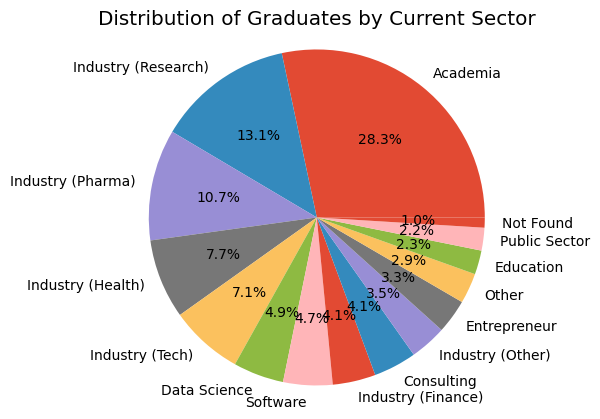

In [9]:
# graduates by sector
counts = students["Sector"].value_counts().reset_index()
plt.pie(counts["count"], labels=counts["Sector"], autopct="%1.1f%%")
plt.axis("equal")
plt.title("Distribution of Graduates by Current Sector")
plt.savefig(f"{figures}sector_pie.png")
plt.show()

## Past jobs


In [10]:
display(jobs.Sector.value_counts().to_frame())

,count
Sector,
Academia,672
Industry (Pharma),159
Industry (Research),106
Consulting,102
Industry (Health),102
Industry (Tech),89
Industry (Biotech),86
Data Science,67
Industry (Finance),66


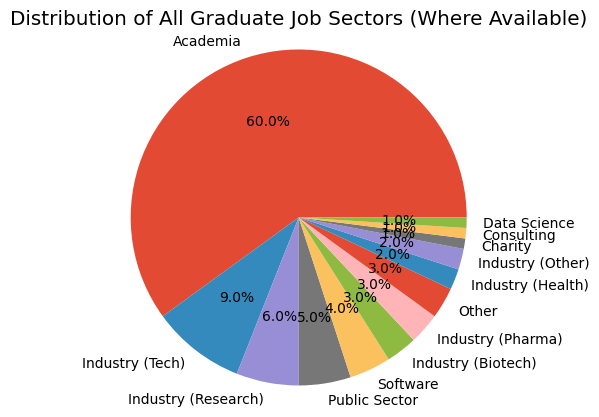

In [11]:
available_sectors = [
    "Academia",
    "Industry (Pharma)",
    "Industry (Research)",
    "Consulting",
    "Industry (Health)",
    "Industry (Tech)",
    "Industry (Biotech)",
    "Data Science",
    "Industry (Finance)",
    "Software",
    "Entrepreneur",
    "Industry (Other)",
    "Public Sector",
    "Other",
    "Education",
    "Industry (Engineering)",
    "Charity",
    "Not Found",
]
jobs_with_correct_sectors = jobs.loc[jobs["Sector"].isin(available_sectors)].dropna()

# pie chart of sectors
counts = jobs_with_correct_sectors["Sector"].value_counts().reset_index()
plt.pie(counts["count"], labels=counts["Sector"], autopct="%1.1f%%")
plt.axis("equal")
plt.title("Distribution of All Graduate Job Sectors (Where Available)")
plt.savefig(f"{figures}sector_pie.png")
plt.show()

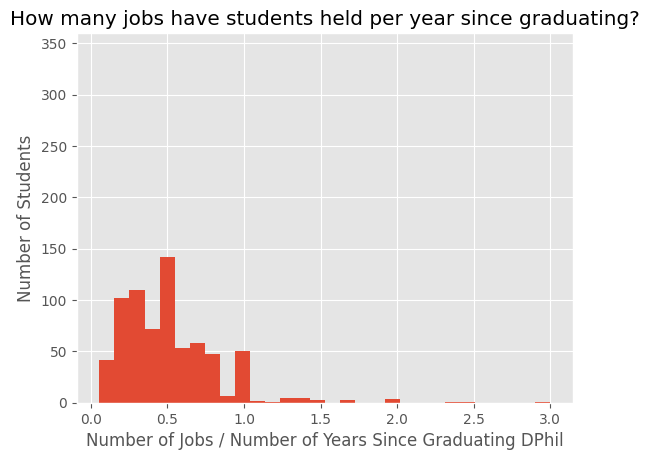

NB some roles are held concurrently. This is not accounted for in the above plot.


In [12]:
current_year = datetime.now().year
num_jobs_stand = jobs["Name"].value_counts().reset_index()
num_jobs_stand["Year"] = None

num_jobs_stand = num_jobs_stand.loc[num_jobs_stand["Year"] != 0]
for name in num_jobs_stand["Name"]:
    relevant_row = students.loc[students.Name == name]
    # Check if the relevant row is empty
    year = relevant_row["Thesis Year"].values[0]
    if pd.isna(year):
        num_jobs_stand.loc[num_jobs_stand["Name"] == name, "Year"] = current_year
    else:
        num_jobs_stand.loc[num_jobs_stand["Name"] == name, "Year"] = year
num_jobs_stand["years_since"] = current_year - num_jobs_stand["Year"].copy()
num_jobs_stand["jobs_time"] = num_jobs_stand["count"] / num_jobs_stand["years_since"]
num_jobs_stand.jobs_time.plot(kind="hist", bins=30)
plt.title("How many jobs have students held per year since graduating?")
plt.xlabel("Number of Jobs / Number of Years Since Graduating DPhil")
plt.ylabel("Number of Students")
plt.ylim(0, 360)
plt.show()

print(
    "NB some roles are held concurrently. This is not accounted for in the above plot."
)

## Career progression

373


,time_to_leave,count
0,4.0,11
1,Never left,160
2,0.0,66
3,8.0,2
4,1.0,64
5,5.0,11
6,6.0,1
7,3.0,20
8,2.0,31
9,11.0,1


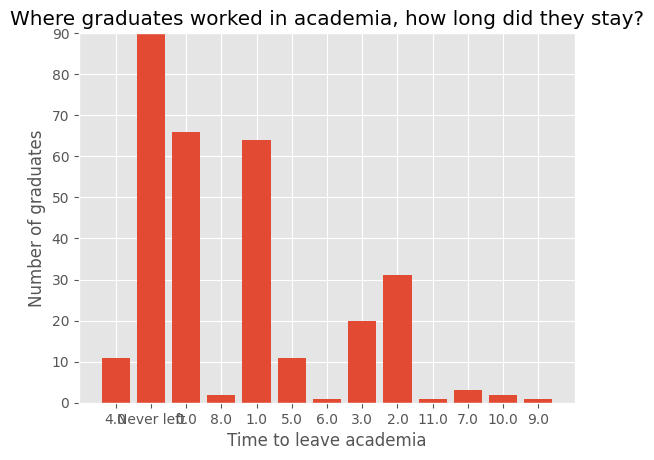

AttributeError: 'float' object has no attribute 'lower'

In [13]:
academia_subset = jobs.copy()
to_exclude = []

for name in academia_subset["Name"]:
    relevant_subset = academia_subset.loc[academia_subset.Name == name]
    # check if ever worked in academia
    if relevant_subset["Sector"].str.contains("Academia").any():
        pass
    else:
        to_exclude.append(name)

# remove those who have never worked in academia
academia_subset = academia_subset[~academia_subset["Name"].isin(to_exclude)]

print(academia_subset.Name.nunique())

academia_time = pd.DataFrame()
academia_time["Name"] = academia_subset["Name"].unique()

academia_time["time_to_leave"] = np.nan

for name in academia_time.Name:
    relevant_rows = academia_subset.loc[academia_subset.Name == name]
    # check the time of the first non-academic job
    non_academia_jobs = relevant_rows[relevant_rows["Sector"] != "Academia"]
    if non_academia_jobs.shape[0] == 0:
        academia_time.loc[academia_time["Name"] == name, "time_to_leave"] = np.nan
    else:
        time_to_leave = non_academia_jobs["years_since"].min()
        academia_time.loc[academia_time["Name"] == name, "time_to_leave"] = (
            time_to_leave
        )

academia_time.time_to_leave = academia_time.time_to_leave.astype(object)
academia_time.time_to_leave = academia_time.time_to_leave.replace(
    {np.nan: "Never left"}
)

counts = academia_time.time_to_leave.value_counts(sort=False).reset_index()
display(counts)
plt.bar(
    x=counts["time_to_leave"].astype(str),
    height=counts["count"],
)

plt.title("Where graduates worked in academia, how long did they stay?")
plt.xlabel("Time to leave academia")
plt.ylabel("Number of graduates")
plt.ylim(0, 90)
plt.show()

# time to professorship
professorship = pd.DataFrame()
professorship["Name"] = academia_subset["Name"].unique()
professorship["time_to_prof"] = np.nan
for name in professorship.Name:
    relevant_rows = academia_subset.loc[academia_subset.Name == name]
    # check the time of the first non-academic job
    any_prof_job = (
        sum(["professor" in i.lower() for i in relevant_rows["Job Title"]]) > 0
    )
    if any_prof_job:
        prof_jobs = relevant_rows[
            relevant_rows["Job Title"].str.contains("professor", case=False)
        ]
        time_to_prof = prof_jobs["years_since"].min()
    else:
        time_to_prof = np.nan

    professorship.loc[professorship["Name"] == name, "time_to_prof"] = time_to_prof

# professorship.time_to_prof = professorship.time_to_prof.astype(object)
# professorship.time_to_prof = professorship.time_to_prof.replace({np.nan: 'Never became professor'})
professorship = professorship.dropna(subset="time_to_prof")
counts = professorship.time_to_prof.value_counts(sort=False).reset_index()
display(counts)
plt.bar(
    x=counts["time_to_prof"].astype(str),
    height=counts["count"],
)
plt.title("Where graduates have attained professorship, how long it take them?")
plt.xlabel("Time to professorship")
plt.ylabel("Number of graduates")
plt.show()

,count
Company,
university of oxford,486
imperial college london,20
gsk,19
ucl,19
oxford nanopore technologies,18
perspectum,16
kcl,15
university of cambridge,15
benevolentai,14


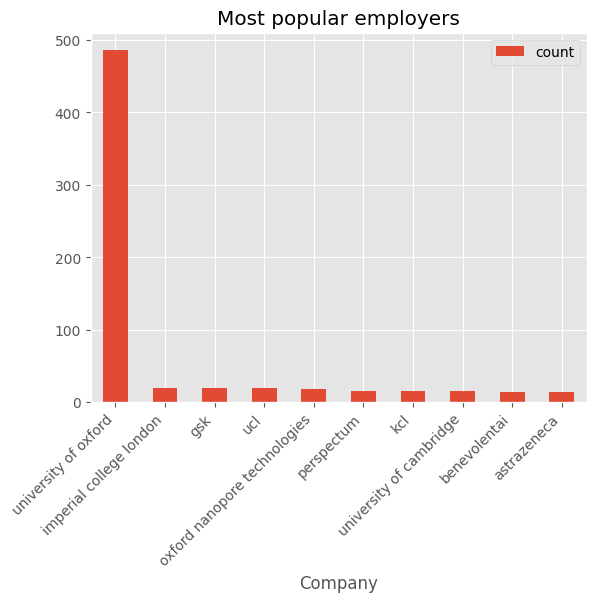

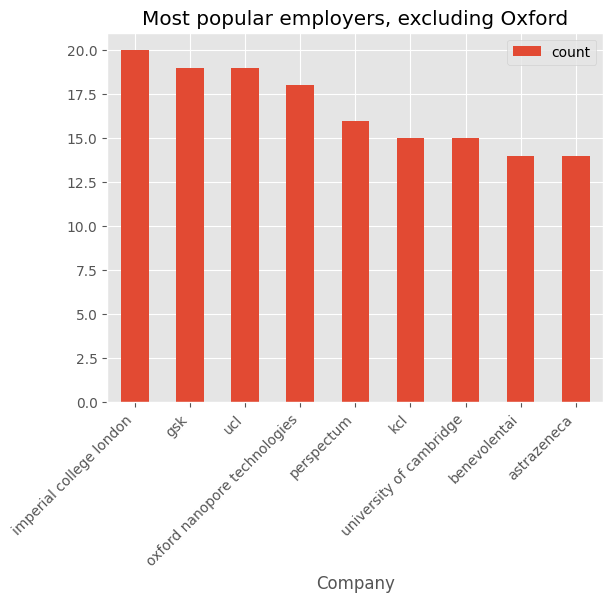

In [ ]:
# ensure only jobs held SINCE graduating
employers = jobs.Company.dropna().str.lower()


for i, name in enumerate(employers):
    if "university of oxford" in name:
        print
        employers.loc[i] = "university of oxford"
    elif "college oxford" in name:
        employers.loc[i] = "university of oxford"
    else:
        pass

counts = employers.value_counts().to_frame()
counts = counts.loc[counts["count"] > 10]
display(counts)
counts.plot.bar()
plt.title("Most popular employers")
plt.xticks(rotation=45, ha="right")
plt.show()

# exclude oxford
counts[counts.index != "university of oxford"].plot.bar()
plt.title("Most popular employers, excluding Oxford")
plt.xticks(rotation=45, ha="right")
plt.show()